Import relevant metrics

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cv = pd.read_csv("CVTest.csv")

In [5]:
yolo = pd.read_csv("YOLOTest.csv")

In [7]:
cv.head()

,id,count
0,0,16
1,1,20
2,2,17
3,3,16
4,4,25


In [9]:
yolo.head()

,id,count
0,0,14
1,1,20
2,2,13
3,3,14
4,4,20


In [11]:
real = pd.read_csv("labels.csv")

In [13]:
real.head()

,id,count
0,1,35
1,2,41
2,3,41
3,4,44
4,5,41


After getting all relevant files, using pandas to get only the relevant count data.

In [15]:
real_totals = real["count"]

In [17]:
real_totals.head()

0    35
1    41
2    41
3    44
4    41
Name: count, dtype: int64

In [19]:
cv_totals = cv['count']

In [21]:
cv_totals.head()

0    16
1    20
2    17
3    16
4    25
Name: count, dtype: int64

In [23]:
cv_totals.truncate(after=299)

0      16
1      20
2      17
3      16
4      25
       ..
295    12
296    14
297    18
298    18
299    15
Name: count, Length: 300, dtype: int64

In [25]:
yolo_totals = yolo['count']

In [27]:
yolo_totals.head()

0    14
1    20
2    13
3    14
4    20
Name: count, dtype: int64

In [127]:
yolo_totals

0      14
1      20
2      13
3      14
4      20
       ..
295     9
296    10
297    16
298    13
299    13
Name: count, Length: 300, dtype: int64

In [37]:
len(real_totals)

300

In [33]:
real_totals = real_totals.truncate(after=299)

In [35]:
cv_totals = cv_totals.truncate(after=299)

In [137]:
l_real_totals = real['count'].truncate(after=299).tolist()
l_cv_totals = cv['count'].truncate(after=299).tolist()
l_yolo_totals = yolo['count'].truncate(after=299).tolist()

Calculate mean accuracy.

In [139]:
def get_acc(list):
    accuracy = []
    for i in range(len(list)):
        x = list[i]/l_real_totals[i]
        accuracy.append(x)
    return accuracy

In [141]:
cv_acc = get_acc(l_cv_totals)

In [143]:
yolo_acc = get_acc(l_yolo_totals)

In [145]:
cv_acc

[0.45714285714285713,
 0.4878048780487805,
 0.4146341463414634,
 0.36363636363636365,
 0.6097560975609756,
 0.3902439024390244,
 0.7142857142857143,
 0.6388888888888888,
 0.5185185185185185,
 0.625,
 0.875,
 0.6818181818181818,
 0.4782608695652174,
 0.56,
 0.6,
 0.75,
 0.4666666666666667,
 0.48,
 0.4838709677419355,
 0.92,
 0.5833333333333334,
 0.6538461538461539,
 0.6521739130434783,
 0.4782608695652174,
 0.5909090909090909,
 0.5652173913043478,
 0.47619047619047616,
 0.30434782608695654,
 0.46153846153846156,
 0.5555555555555556,
 0.7391304347826086,
 0.8636363636363636,
 0.7619047619047619,
 0.5263157894736842,
 0.631578947368421,
 0.30434782608695654,
 0.6,
 0.52,
 0.37037037037037035,
 0.4,
 0.3333333333333333,
 0.7619047619047619,
 0.7,
 0.6,
 0.375,
 0.5454545454545454,
 0.5238095238095238,
 0.5555555555555556,
 0.4642857142857143,
 0.72,
 0.6842105263157895,
 0.4666666666666667,
 0.35294117647058826,
 0.6111111111111112,
 0.4583333333333333,
 0.37037037037037035,
 0.56521739130

In [147]:
yolo_acc

[0.4,
 0.4878048780487805,
 0.3170731707317073,
 0.3181818181818182,
 0.4878048780487805,
 0.36585365853658536,
 0.42857142857142855,
 0.3611111111111111,
 0.2222222222222222,
 0.20833333333333334,
 0.3125,
 0.2727272727272727,
 0.391304347826087,
 0.44,
 0.2,
 0.5,
 0.2,
 0.48,
 0.3870967741935484,
 0.56,
 0.625,
 0.11538461538461539,
 0.5652173913043478,
 0.391304347826087,
 0.22727272727272727,
 0.4782608695652174,
 0.42857142857142855,
 0.34782608695652173,
 0.5,
 0.5185185185185185,
 0.34782608695652173,
 0.5,
 0.47619047619047616,
 0.21052631578947367,
 0.3157894736842105,
 0.391304347826087,
 0.44,
 0.36,
 0.5185185185185185,
 0.44,
 0.2916666666666667,
 0.47619047619047616,
 0.5,
 0.5,
 0.5,
 0.2727272727272727,
 0.42857142857142855,
 0.5,
 0.2857142857142857,
 0.6,
 0.5263157894736842,
 0.13333333333333333,
 0.35294117647058826,
 0.4444444444444444,
 0.3333333333333333,
 0.2962962962962963,
 0.4782608695652174,
 0.5,
 0.48148148148148145,
 0.5,
 0.1875,
 0.375,
 0.5,
 0.434782

In [149]:
import statistics as st

In [153]:
mean_cv_acc = st.mean(cv_acc)
mean_yolo_acc = st.mean(yolo_acc)

In [157]:
mean_cv_acc

0.47692970148116337

In [159]:
mean_yolo_acc

0.3523313362385411

In [161]:
import numpy as np

Create graphs.

In [193]:
np_totals_cv = np.array(l_cv_totals)
np_totals_real = np.array(l_real_totals)
np_totals_yolo = np.array(l_yolo_totals)

font = {'family':'serif'}


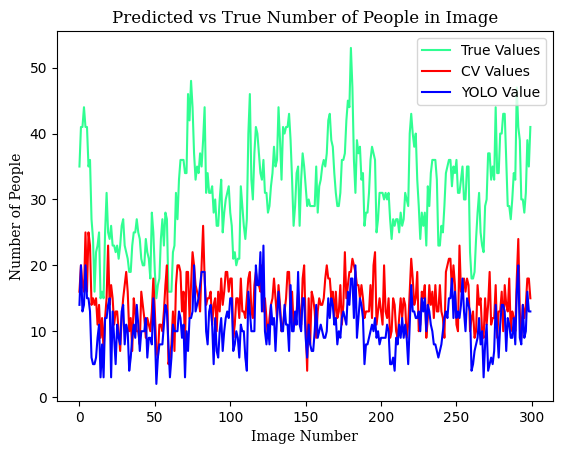

In [219]:
plt.plot(np_totals_real, color="#30fe92", label="True Values")
plt.plot(np_totals_cv, color="red", label="CV Values")
plt.plot(np_totals_yolo, color="blue", label="YOLO Value")
plt.title("Predicted vs True Number of People in Image", fontdict=font)
plt.xlabel("Image Number", fontdict=font)
plt.ylabel("Number of People", fontdict=font)
plt.legend()
plt.show()

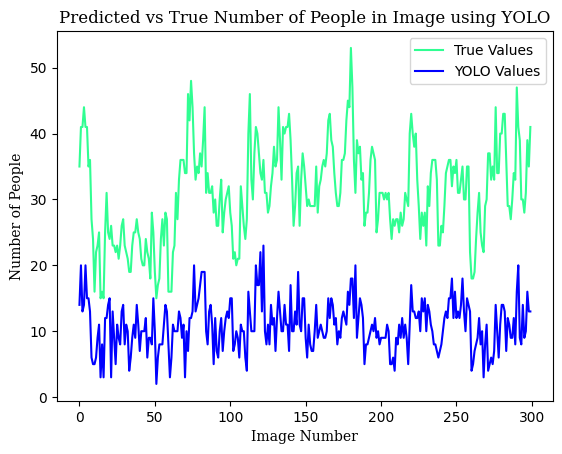

In [213]:
plt.plot(np_totals_real, color="#30fe92", label="True Values")
plt.plot(np_totals_yolo, color="blue", label="YOLO Values")
plt.title("Predicted vs True Number of People in Image using YOLO", fontdict=font)
plt.xlabel("Image Number", fontdict=font)
plt.ylabel("Number of People", fontdict=font)
plt.legend()
plt.show()

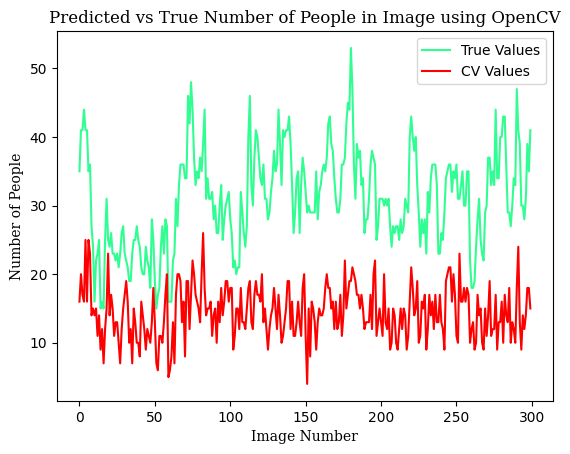

In [211]:
plt.plot(np_totals_real, color="#30fe92", label="True Values")
plt.plot(np_totals_cv, color="red", label="CV Values")
plt.title("Predicted vs True Number of People in Image using OpenCV", fontdict=font)
plt.xlabel("Image Number", fontdict=font)
plt.ylabel("Number of People", fontdict=font)
plt.legend()
plt.show()